In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns 
import matplotlib.pyplot as plt
import missingno as msno
import plotly.graph_objs as go
import plotly.express as px
plt.style.use('seaborn-dark')
plt.style.context('grayscale')
%matplotlib inline
from wordcloud import WordCloud, STOPWORDS

In [2]:
df=pd.read_csv("/kaggle/input/student-mental-health/Student Mental health.csv")

In [3]:
df.head()

,Timestamp,Choose your gender,Age,What is your course?,Your current year of Study,What is your CGPA?,Marital status,Do you have Depression?,Do you have Anxiety?,Do you have Panic attack?,Did you seek any specialist for a treatment?
0,8/7/2020 12:02,Female,18.0,Engineering,year 1,3.00 - 3.49,No,Yes,No,Yes,No
1,8/7/2020 12:04,Male,21.0,Islamic education,year 2,3.00 - 3.49,No,No,Yes,No,No
2,8/7/2020 12:05,Male,19.0,BIT,Year 1,3.00 - 3.49,No,Yes,Yes,Yes,No
3,8/7/2020 12:06,Female,22.0,Laws,year 3,3.00 - 3.49,Yes,Yes,No,No,No
4,8/7/2020 12:13,Male,23.0,Mathemathics,year 4,3.00 - 3.49,No,No,No,No,No


In [4]:
df.isnull().sum()

Timestamp                                       0
Choose your gender                              0
Age                                             1
What is your course?                            0
Your current year of Study                      0
What is your CGPA?                              0
Marital status                                  0
Do you have Depression?                         0
Do you have Anxiety?                            0
Do you have Panic attack?                       0
Did you seek any specialist for a treatment?    0
dtype: int64

In [5]:
df.Age.mean()

20.53

In [6]:
df.Age.fillna("21",inplace=True)

In [7]:
df.Age.isnull().sum()

0

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 11 columns):
 #   Column                                        Non-Null Count  Dtype 
---  ------                                        --------------  ----- 
 0   Timestamp                                     101 non-null    object
 1   Choose your gender                            101 non-null    object
 2   Age                                           101 non-null    object
 3   What is your course?                          101 non-null    object
 4   Your current year of Study                    101 non-null    object
 5   What is your CGPA?                            101 non-null    object
 6   Marital status                                101 non-null    object
 7   Do you have Depression?                       101 non-null    object
 8   Do you have Anxiety?                          101 non-null    object
 9   Do you have Panic attack?                     101 non-null    object
 10  Di

In [9]:
df.shape

(101, 11)

In [10]:
df.rename(columns = {'Choose your gender':'Choose_your_gender',
                     'What is your course?':'What_is_your_course', 
                     'Your current year of Study':'Your_current_year_of_Study',
                     'What is your CGPA?':'What_is_your_CGPA', 
                     'Marital status':'Marital_status', 
                     'Do you have Depression?':'Do_you_have_Depression', 
                     'Do you have Anxiety?':'Do_you_have_Anxiety',
                     'Do you have Panic attack?':'Do_you_have_Panic_attack', 
                     'Did you seek any specialist for a treatment?':'Did_you_seek_any_specialist_for_a_treatment'}, inplace = True) 

In [11]:
df.head()

,Timestamp,Choose_your_gender,Age,What_is_your_course,Your_current_year_of_Study,What_is_your_CGPA,Marital_status,Do_you_have_Depression,Do_you_have_Anxiety,Do_you_have_Panic_attack,Did_you_seek_any_specialist_for_a_treatment
0,8/7/2020 12:02,Female,18.0,Engineering,year 1,3.00 - 3.49,No,Yes,No,Yes,No
1,8/7/2020 12:04,Male,21.0,Islamic education,year 2,3.00 - 3.49,No,No,Yes,No,No
2,8/7/2020 12:05,Male,19.0,BIT,Year 1,3.00 - 3.49,No,Yes,Yes,Yes,No
3,8/7/2020 12:06,Female,22.0,Laws,year 3,3.00 - 3.49,Yes,Yes,No,No,No
4,8/7/2020 12:13,Male,23.0,Mathemathics,year 4,3.00 - 3.49,No,No,No,No,No


In [12]:
df['Date'] = pd.to_datetime(df['Timestamp'], errors='coerce')
df['day'] = (df['Date']).dt.day
df['month'] = (df['Date']).dt.month
df['year'] = (df['Date']).dt.year
df['hour'] = (df['Date']).dt.hour

In [13]:
df.head()

,Timestamp,Choose_your_gender,Age,What_is_your_course,Your_current_year_of_Study,What_is_your_CGPA,Marital_status,Do_you_have_Depression,Do_you_have_Anxiety,Do_you_have_Panic_attack,Did_you_seek_any_specialist_for_a_treatment,Date,day,month,year,hour
0,8/7/2020 12:02,Female,18.0,Engineering,year 1,3.00 - 3.49,No,Yes,No,Yes,No,2020-08-07 12:02:00,7,8,2020,12
1,8/7/2020 12:04,Male,21.0,Islamic education,year 2,3.00 - 3.49,No,No,Yes,No,No,2020-08-07 12:04:00,7,8,2020,12
2,8/7/2020 12:05,Male,19.0,BIT,Year 1,3.00 - 3.49,No,Yes,Yes,Yes,No,2020-08-07 12:05:00,7,8,2020,12
3,8/7/2020 12:06,Female,22.0,Laws,year 3,3.00 - 3.49,Yes,Yes,No,No,No,2020-08-07 12:06:00,7,8,2020,12
4,8/7/2020 12:13,Male,23.0,Mathemathics,year 4,3.00 - 3.49,No,No,No,No,No,2020-08-07 12:13:00,7,8,2020,12


In [14]:
df.year.value_counts()

2020    101
Name: year, dtype: int64

In [16]:
fig = px.histogram(df, x="day", color="day")
fig.show()

 <span style="color:red;font-family:serif; font-size:28px;"> This survey was usually done on the 7th. </span>

In [17]:
df.month.value_counts()

8    73
7    23
9     5
Name: month, dtype: int64

In [18]:
fig = px.histogram(df, x="month", color="month")
fig.show()

 <span style="color:red;font-family:serif; font-size:28px;"> This survey was started at the 8th month and continued at the 9th and 10th months. </span>

In [19]:
df.hour.value_counts()

12    18
14    16
13    13
15    13
10     9
16     7
17     5
11     5
19     4
21     4
18     3
20     2
22     1
6      1
Name: hour, dtype: int64

In [20]:
fig = px.histogram(df, x="hour", color="hour")
fig.show()


 <span style="color:red;font-family:serif; font-size:28px;"> This survey was usually done at noon. </span>

In [21]:
df.Choose_your_gender.value_counts()

Female    75
Male      26
Name: Choose_your_gender, dtype: int64

In [22]:
fig = px.histogram(df, x="Choose_your_gender", color="Choose_your_gender")
fig.show()

 <span style="color:red;font-family:serif; font-size:28px;"> The survey was mostly answered by women. </span>

In [23]:
df.Age.value_counts()

18.0    32
24.0    23
19.0    21
23.0    13
20.0     6
21.0     3
22.0     2
21       1
Name: Age, dtype: int64

In [24]:
fig = px.histogram(df, x="Age", color="Age")
fig.show()

 <span style="color:red;font-family:serif; font-size:28px;"> Respondents are usually 18-year-olds, presumably in their first year at university. </span>

In [25]:
df.What_is_your_course.value_counts()

BCS                        18
Engineering                17
BIT                        10
Biomedical science          4
KOE                         4
BENL                        2
Laws                        2
psychology                  2
Engine                      2
Islamic Education           1
Biotechnology               1
engin                       1
Econs                       1
MHSC                        1
Malcom                      1
Kop                         1
Human Sciences              1
Communication               1
Nursing                     1
Diploma Nursing             1
IT                          1
Pendidikan Islam            1
Radiography                 1
Fiqh fatwa                  1
DIPLOMA TESL                1
Koe                         1
Fiqh                        1
CTS                         1
koe                         1
Benl                        1
Kirkhs                      1
Mathemathics                1
Pendidikan islam            1
Human Reso

In [26]:
fig = px.histogram(df, x="What_is_your_course", color="What_is_your_course")
fig.show()

 <span style="color:red;font-family:serif; font-size:28px;"> Participants usually consist of people from the 4-year department. </span>

In [27]:
df.head()

,Timestamp,Choose_your_gender,Age,What_is_your_course,Your_current_year_of_Study,What_is_your_CGPA,Marital_status,Do_you_have_Depression,Do_you_have_Anxiety,Do_you_have_Panic_attack,Did_you_seek_any_specialist_for_a_treatment,Date,day,month,year,hour
0,8/7/2020 12:02,Female,18.0,Engineering,year 1,3.00 - 3.49,No,Yes,No,Yes,No,2020-08-07 12:02:00,7,8,2020,12
1,8/7/2020 12:04,Male,21.0,Islamic education,year 2,3.00 - 3.49,No,No,Yes,No,No,2020-08-07 12:04:00,7,8,2020,12
2,8/7/2020 12:05,Male,19.0,BIT,Year 1,3.00 - 3.49,No,Yes,Yes,Yes,No,2020-08-07 12:05:00,7,8,2020,12
3,8/7/2020 12:06,Female,22.0,Laws,year 3,3.00 - 3.49,Yes,Yes,No,No,No,2020-08-07 12:06:00,7,8,2020,12
4,8/7/2020 12:13,Male,23.0,Mathemathics,year 4,3.00 - 3.49,No,No,No,No,No,2020-08-07 12:13:00,7,8,2020,12


In [28]:
df.loc[(df['Your_current_year_of_Study'] =="Year 3"), 'Your_current_year_of_Study'] = 'year 3'
df.loc[(df['Your_current_year_of_Study'] =="Year 2"), 'Your_current_year_of_Study'] = 'year 2'
df.loc[(df['Your_current_year_of_Study'] =="Year 1"), 'Your_current_year_of_Study'] = 'year 1'


In [29]:
df.Your_current_year_of_Study.value_counts()

year 1    43
year 2    26
year 3    24
year 4     8
Name: Your_current_year_of_Study, dtype: int64

In [30]:
fig = px.histogram(df, x="Your_current_year_of_Study", color="Your_current_year_of_Study")
fig.show()

 <span style="color:red;font-family:serif; font-size:28px;"> Respondents to the questionnaire generally consist of first-year students. </span>

In [31]:
df.What_is_your_CGPA.value_counts()

3.50 - 4.00     47
3.00 - 3.49     43
2.50 - 2.99      4
0 - 1.99         4
2.00 - 2.49      2
3.50 - 4.00      1
Name: What_is_your_CGPA, dtype: int64

In [32]:
fig = px.histogram(df, x="What_is_your_CGPA", color="What_is_your_CGPA")
fig.show()

 <span style="color:red;font-family:serif; font-size:28px;"> The average of respondents to the survey is between 3.5 and 4. </span>

In [33]:
df.Marital_status.value_counts()

No     85
Yes    16
Name: Marital_status, dtype: int64

In [34]:
fig = px.histogram(df, x="Marital_status", color="Marital_status")
fig.show()

 <span style="color:red;font-family:serif; font-size:28px;"> marital status is generally single. </span>

In [35]:
df.Do_you_have_Depression.value_counts()

No     66
Yes    35
Name: Do_you_have_Depression, dtype: int64

In [36]:
fig = px.histogram(df, x="Do_you_have_Depression", color="Do_you_have_Depression")
fig.show()

 <span style="color:red;font-family:serif; font-size:28px;"> They are not usually depressed. </span>

In [37]:
df.head()

,Timestamp,Choose_your_gender,Age,What_is_your_course,Your_current_year_of_Study,What_is_your_CGPA,Marital_status,Do_you_have_Depression,Do_you_have_Anxiety,Do_you_have_Panic_attack,Did_you_seek_any_specialist_for_a_treatment,Date,day,month,year,hour
0,8/7/2020 12:02,Female,18.0,Engineering,year 1,3.00 - 3.49,No,Yes,No,Yes,No,2020-08-07 12:02:00,7,8,2020,12
1,8/7/2020 12:04,Male,21.0,Islamic education,year 2,3.00 - 3.49,No,No,Yes,No,No,2020-08-07 12:04:00,7,8,2020,12
2,8/7/2020 12:05,Male,19.0,BIT,year 1,3.00 - 3.49,No,Yes,Yes,Yes,No,2020-08-07 12:05:00,7,8,2020,12
3,8/7/2020 12:06,Female,22.0,Laws,year 3,3.00 - 3.49,Yes,Yes,No,No,No,2020-08-07 12:06:00,7,8,2020,12
4,8/7/2020 12:13,Male,23.0,Mathemathics,year 4,3.00 - 3.49,No,No,No,No,No,2020-08-07 12:13:00,7,8,2020,12


In [38]:
df.Do_you_have_Anxiety.value_counts()

No     67
Yes    34
Name: Do_you_have_Anxiety, dtype: int64

In [39]:
fig = px.histogram(df, x="Do_you_have_Anxiety", color="Do_you_have_Anxiety")
fig.show()

 <span style="color:red;font-family:serif; font-size:28px;"> They usually do not have anxiety problems. </span>

In [40]:
df.Do_you_have_Panic_attack.value_counts()

No     68
Yes    33
Name: Do_you_have_Panic_attack, dtype: int64

In [41]:
fig = px.histogram(df, x="Do_you_have_Panic_attack", color="Do_you_have_Panic_attack")
fig.show()

 <span style="color:red;font-family:serif; font-size:28px;">They usually do not experience panic attacks. </span>


In [42]:
df.Did_you_seek_any_specialist_for_a_treatment.value_counts()

No     95
Yes     6
Name: Did_you_seek_any_specialist_for_a_treatment, dtype: int64

In [43]:
fig = px.histogram(df, x="Did_you_seek_any_specialist_for_a_treatment", color="Did_you_seek_any_specialist_for_a_treatment")
fig.show()

 <span style="color:red;font-family:serif; font-size:28px;">They often do not receive expert support. </span>


In [44]:
df.head()

,Timestamp,Choose_your_gender,Age,What_is_your_course,Your_current_year_of_Study,What_is_your_CGPA,Marital_status,Do_you_have_Depression,Do_you_have_Anxiety,Do_you_have_Panic_attack,Did_you_seek_any_specialist_for_a_treatment,Date,day,month,year,hour
0,8/7/2020 12:02,Female,18.0,Engineering,year 1,3.00 - 3.49,No,Yes,No,Yes,No,2020-08-07 12:02:00,7,8,2020,12
1,8/7/2020 12:04,Male,21.0,Islamic education,year 2,3.00 - 3.49,No,No,Yes,No,No,2020-08-07 12:04:00,7,8,2020,12
2,8/7/2020 12:05,Male,19.0,BIT,year 1,3.00 - 3.49,No,Yes,Yes,Yes,No,2020-08-07 12:05:00,7,8,2020,12
3,8/7/2020 12:06,Female,22.0,Laws,year 3,3.00 - 3.49,Yes,Yes,No,No,No,2020-08-07 12:06:00,7,8,2020,12
4,8/7/2020 12:13,Male,23.0,Mathemathics,year 4,3.00 - 3.49,No,No,No,No,No,2020-08-07 12:13:00,7,8,2020,12


In [45]:
fig = px.histogram(df, x="Do_you_have_Depression",
             color='Did_you_seek_any_specialist_for_a_treatment', barmode='group',
             height=400)
fig.show()

 <span style="color:red;font-family:serif; font-size:28px;">Some of those who are depressed receive professional support. </span>


In [46]:
fig = px.histogram(df, x="Do_you_have_Anxiety",
             color='Did_you_seek_any_specialist_for_a_treatment', barmode='group',
             height=400)
fig.show()

 <span style="color:red;font-family:serif; font-size:28px;">Some of those experiencing anxiety receive professional support. When this percentage is multiplied, it is higher than for those who show symptoms of depression. </span>


In [47]:
fig = px.histogram(df, x="Do_you_have_Panic_attack",
             color='Did_you_seek_any_specialist_for_a_treatment', barmode='group',
             height=400)
fig.show()

 <span style="color:red;font-family:serif; font-size:28px;">Some of those experiencing panic attacks receive professional support. This rate is higher than others. </span>


In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 16 columns):
 #   Column                                       Non-Null Count  Dtype         
---  ------                                       --------------  -----         
 0   Timestamp                                    101 non-null    object        
 1   Choose_your_gender                           101 non-null    object        
 2   Age                                          101 non-null    object        
 3   What_is_your_course                          101 non-null    object        
 4   Your_current_year_of_Study                   101 non-null    object        
 5   What_is_your_CGPA                            101 non-null    object        
 6   Marital_status                               101 non-null    object        
 7   Do_you_have_Depression                       101 non-null    object        
 8   Do_you_have_Anxiety                          101 non-null    object        
 9  

In [49]:
fig = px.box(df, x="Choose_your_gender", y="Age",color="Choose_your_gender", notched=True, # used notched shape
             title="Box plot of Gender",)
fig.show()

 <span style="color:red;font-family:serif; font-size:28px;">The average age of men is higher than that of women. However, the number of women in this dataset was high. Then we can say that the age of the men who answered this questionnaire is more than the age of the women. For example, if the age of women responding is around 18, the average age of men varies between 18-24. </span>


In [50]:
fig = px.box(df, x="Marital_status", y="Age",color="Marital_status", notched=True, # used notched shape
             title="Box plot of status")
fig.show()

<span style="color:red;font-family:serif; font-size:28px;">Since the age of marriage is 18 and over in the law, the average age of married people is 21. </span>


In [51]:
fig = px.box(df, x="Your_current_year_of_Study", y="Age",color="Your_current_year_of_Study", notched=True, # used notched shape
             title="Box plot of study",)
fig.show()

<span style="color:red;font-family:serif; font-size:28px;">While the average age of the 1st and 2nd year students is close to each other, the average age increases as the grade level increases.</span>


<a id="5"></a>
# <p style="padding:10px;background-color:lightblue;margin:0;color:black;font-family:newtimeroman;font-size:100%;text-align:center;border-radius: 15px 50px;overflow:hidden;font-weight:500">AUTHOR MESSAGE</p>

<span style="color:blue;font-family:serif; font-size:28px;"> 🔵 If you liked this Notebook, please do upvote. If you have any questions, feel free to comment! Best Wishes 🔵 </span>
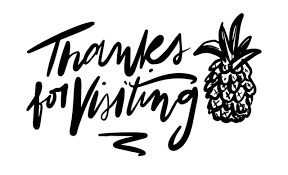

# <a href="https://www.linkedin.com/in/melike-dilekci-727224204">https://www.linkedin.com/in/melike-dilekci-727224204</a>

## 6. Model Training And Deployment Prep

This section trains a classifier to predict depression status and saves the trained pipeline for application deployment.

In [ ]:
from pathlib import Path
import json
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

DATA_CANDIDATES = [
    Path('data/Student Mental health.csv'),
    Path('Student Mental health.csv'),
    Path('/kaggle/input/student-mental-health/Student Mental health.csv'),
]

def load_dataset():
    for path in DATA_CANDIDATES:
        if path.exists():
            print(f'Loaded dataset from: {path}')
            return pd.read_csv(path)
    raise FileNotFoundError(
        'Dataset not found. Put Student Mental health.csv in data/ or project root.'
    )

raw_df = load_dataset()
raw_df.head()

In [ ]:
# Standardize column names to support both Kaggle and local usage.
df_model = raw_df.rename(columns={
    'Choose your gender': 'Choose_your_gender',
    'What is your course?': 'What_is_your_course',
    'Your current year of Study': 'Your_current_year_of_Study',
    'What is your CGPA?': 'What_is_your_CGPA',
    'Marital status': 'Marital_status',
    'Do you have Depression?': 'Do_you_have_Depression',
    'Do you have Anxiety?': 'Do_you_have_Anxiety',
    'Do you have Panic attack?': 'Do_you_have_Panic_attack',
    'Did you seek any specialist for a treatment?': 'Did_you_seek_any_specialist_for_a_treatment',
})

target_col = 'Do_you_have_Depression'
if target_col not in df_model.columns:
    raise KeyError(f'Missing target column: {target_col}')

# Drop leakage/time columns not useful for inference forms.
drop_cols = [c for c in ['Timestamp', 'Date', 'day', 'month', 'year', 'hour'] if c in df_model.columns]
feature_df = df_model.drop(columns=drop_cols)

feature_cols = [c for c in feature_df.columns if c != target_col]
X = feature_df[feature_cols].copy()
y = feature_df[target_col].astype(str).str.strip().str.lower()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()
num_cols = [c for c in X_train.columns if c not in cat_cols]

preprocess = ColumnTransformer(
    transformers=[
        ('num', Pipeline([('imputer', SimpleImputer(strategy='median'))]), num_cols),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OneHotEncoder(handle_unknown='ignore')),
        ]), cat_cols),
    ],
    remainder='drop',
)

model = Pipeline(steps=[
    ('preprocess', preprocess),
    ('classifier', RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced')),
])

model.fit(X_train, y_train)
preds = model.predict(X_test)

print('Accuracy:', round(accuracy_score(y_test, preds), 4))
print(classification_report(y_test, preds))

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

artifacts_dir = Path('artifacts')
artifacts_dir.mkdir(exist_ok=True)

model_path = artifacts_dir / 'depression_model.joblib'
metadata_path = artifacts_dir / 'model_metadata.json'
metrics_path = artifacts_dir / 'metrics_summary.json'

joblib.dump(model, model_path)

categorical_options = {}
for col in feature_cols:
    if X[col].dtype == 'object':
        categorical_options[col] = sorted(X[col].dropna().astype(str).unique().tolist())

accuracy = round(float(accuracy_score(y_test, preds)), 4)
class_labels = sorted([str(c) for c in set(y.astype(str))])
report_dict = classification_report(y_test, preds, output_dict=True, zero_division=0)
cm = confusion_matrix(y_test, preds, labels=class_labels)

metadata = {
    'target': target_col,
    'features': feature_cols,
    'classes': sorted(set(y.astype(str))),
    'categorical_options': categorical_options,
    'accuracy': accuracy,
}

metrics_summary = {
    'accuracy': accuracy,
    'test_samples': int(len(y_test)),
    'classification_report': report_dict,
    'class_labels': class_labels,
    'confusion_matrix': cm.tolist(),
}

metadata_path.write_text(json.dumps(metadata, indent=2), encoding='utf-8')
metrics_path.write_text(json.dumps(metrics_summary, indent=2), encoding='utf-8')

print(f'Model saved to: {model_path.resolve()}')
print(f'Metadata saved to: {metadata_path.resolve()}')
print(f'Metrics saved to: {metrics_path.resolve()}')